In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import os

In [6]:
import so as so

In [7]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [8]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [9]:
files = os.listdir('./soDGVAE_dataset/dataset/3_multi_tech_brain/')
files

['mouse_brain1_salus_0.8um.h5ad',
 'mouse_brain21A_ST_100um.h5ad',
 'mouse_brain43_slideseq_1um.h5ad',
 'mouse_brain_VisiumHD_16um.h5ad',
 'mouse_brain_bmk1_2.5um.h5ad',
 'mouse_brain_visium1_55um.h5ad',
 'mouse_brainWhole_curio_10um.h5ad',
 'mouse_brain_DynaSpatial_50um.h5ad',
 '0_statistics.ipynb',
 'mouse_brain_decoder_50um.h5ad',
 '.ipynb_checkpoints',
 'mouse_brain_stereo_50bin_25um.h5ad']

In [10]:
files = [
'mouse_brain21A_ST_100um.h5ad',
'mouse_brain_visium1_55um.h5ad',
'mouse_brain_DynaSpatial_50um.h5ad',
'mouse_brain_decoder_50um.h5ad',
'mouse_brain_stereo_50bin_25um.h5ad',
'mouse_brain_VisiumHD_16um.h5ad',
'mouse_brainWhole_curio_10um.h5ad',
'mouse_brain_bmk1_2.5um.h5ad',
'mouse_brain43_slideseq_1um.h5ad',
'mouse_brain1_salus_0.8um.h5ad',
]
files

['mouse_brain21A_ST_100um.h5ad',
 'mouse_brain_visium1_55um.h5ad',
 'mouse_brain_DynaSpatial_50um.h5ad',
 'mouse_brain_decoder_50um.h5ad',
 'mouse_brain_stereo_50bin_25um.h5ad',
 'mouse_brain_VisiumHD_16um.h5ad',
 'mouse_brainWhole_curio_10um.h5ad',
 'mouse_brain_bmk1_2.5um.h5ad',
 'mouse_brain43_slideseq_1um.h5ad',
 'mouse_brain1_salus_0.8um.h5ad']

# load data

In [11]:
data_list = [sc.read_h5ad(f'./soDGVAE_dataset/dataset/3_multi_tech_brain/{file}') for file in files]
data_list    

[AnnData object with n_obs × n_vars = 620 × 23371
     obs: 'section_index', 'stereo_ML', 'stereo_DV', 'stereo_AP', 'HE_X', 'HE_Y', 'ABA_acronym', 'ABA_name', 'ABA_parent', 'nuclei_segmented', 'spot_radius', 'passed_QC', 'cluster_id', 'cluster_name'
     uns: 'ABA_parent_colors', 'section_index_colors'
     obsm: 'spatial', 'spatial_2d', 'spatial_3d',
 AnnData object with n_obs × n_vars = 4168 × 32285
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA'
     var: 'features'
     obsm: 'X_spatial', 'spatial',
 AnnData object with n_obs × n_vars = 2489 × 32285
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'xcoord', 'ycoord', 'xcoord_ori', 'ycoord_ori'
     var: 'features'
     obsm: 'X_spatial', 'spatial',
 AnnData object with n_obs × n_vars = 2500 × 40162
     obs: 'x', 'y', 'in_tissue', 'n_genes'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 38746 × 26177
     obs: 'annotation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 

In [12]:
batch_names = files
for i, adata in enumerate(data_list):
    adata.obs.loc[:, 'batch'] = files[i]
batch_names

['mouse_brain21A_ST_100um.h5ad',
 'mouse_brain_visium1_55um.h5ad',
 'mouse_brain_DynaSpatial_50um.h5ad',
 'mouse_brain_decoder_50um.h5ad',
 'mouse_brain_stereo_50bin_25um.h5ad',
 'mouse_brain_VisiumHD_16um.h5ad',
 'mouse_brainWhole_curio_10um.h5ad',
 'mouse_brain_bmk1_2.5um.h5ad',
 'mouse_brain43_slideseq_1um.h5ad',
 'mouse_brain1_salus_0.8um.h5ad']

In [13]:
batch_key = 'batch'
adata = so.pp.process_adata(data_list, label=batch_key, keys=batch_names, n_top_features=3000, target_sum=1e4)
adata

AnnData object with n_obs × n_vars = 1263450 × 3000
    obs: 'batch', 'original_index', 'spot_quality'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'mu_bg', 'std_bg'
    obsm: 'spatial'
    layers: 'counts', 'norm_log'

In [14]:
rad_cutoff_list = [8] * len(data_list)
adata, g = so.pp.process_graph(adata, data_list, cutoff_list=rad_cutoff_list, model='KNN')

cal spatial net in data_list
------Calculating spatial graph...
The graph contains 4960 edges, 620 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 33344 edges, 4168 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 19912 edges, 2489 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 20000 edges, 2500 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 309968 edges, 38746 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 791336 edges, 98917 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1783176 edges, 222897 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 2081760 edges, 260220 cells.
8.0000 neighbors per cell on average.
------Calculating spatial

In [15]:
path_results = f'./log/integration_brain_kmeans8/'

In [16]:
adata

AnnData object with n_obs × n_vars = 1263450 × 3000
    obs: 'batch', 'original_index', 'spot_quality'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'mu_bg', 'std_bg', 'adj'
    obsm: 'spatial'
    layers: 'counts', 'norm_log'

In [17]:
adata_int = so.model.DGVAE(adata=adata,
                            n_epoch=5,
                            batch_size=1024,
                            verbose=False,
                            gpu=0,
                            random_seed=42,
                            output_dir=path_results,
                            num_heads=2,
                            h_dim=16,
                            reconstruct_loss='orig',
                            )

clip
reconstruct_loss == orig


Epochs: 100%|█| 5/5 [08:07<00:00, 97.54s/it, recon_loss=472.5242, kl_loss=4.8035, mmd2=0.0000, graph_loss=0.0000, lr: 0.
Infer latent: 100%|█████████████████████████████████████████████████████████████████| 1234/1234 [00:27<00:00, 44.81it/s]


In [18]:
adata_int

AnnData object with n_obs × n_vars = 1263450 × 3000
    obs: 'batch', 'original_index', 'spot_quality'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'mu_bg', 'std_bg', 'adj', 'epoch_loss_df'
    obsm: 'spatial', 'X_soDGVAE'
    layers: 'counts', 'norm_log'

In [19]:
del adata_int.uns['adj']

In [20]:
adata_int.write_h5ad(f'{path_results}adata_int.h5ad', compression='gzip')

In [20]:
adata_int.write_h5ad(f'{path_results}adata_int_10epoch.h5ad', compression='gzip')

In [1]:
import scanpy as sc
import cupy as cp
import time
import rapids_singlecell as rsc
import warnings
warnings.filterwarnings("ignore")

/home/gzh/anaconda3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
import numpy as np
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

def compute_ARI(adata, anno_key, pred_key):
    return adjusted_rand_score(adata.obs[anno_key], adata.obs[pred_key])

def compute_NMI(adata, anno_key, pred_key):
    return normalized_mutual_info_score(adata.obs[anno_key], adata.obs[pred_key])

In [4]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [5]:
def kmeans_cluster(adata, n_clusters=10, used_embedding='X_pca', mode='KMeans', key_add='kmeans'):
    from sklearn.cluster import KMeans, MiniBatchKMeans
    if mode == 'KMeans':
        model = KMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(adata.obsm[used_embedding])
    elif mode == 'MiniBatchKMeans':
        model = MiniBatchKMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(
            adata.obsm[used_embedding])
    else:
        print('mode in [KMeans, MiniBatchKMeans]')
        raise NotImplementedError
    cell_label = model.labels_
    adata.obs.loc[:, key_add] = cell_label
    adata.obs.loc[:, key_add] = adata.obs.loc[:, key_add].astype(str)
    return adata

In [20]:
path_results = f'./log/integration_brain/'

In [7]:
adata_int = sc.read_h5ad(f'{path_results}adata_int_5epoch.h5ad')
adata_int

AnnData object with n_obs × n_vars = 1263450 × 3000
    obs: 'batch', 'original_index', 'spot_quality'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg'
    obsm: 'X_soDGVAE', 'spatial'
    layers: 'counts', 'norm_log'

In [18]:
%%time
rsc.pp.neighbors(adata_int, use_rep='X_soDGVAE')
rsc.tl.umap(adata_int)

CPU times: user 5.87 s, sys: 625 ms, total: 6.49 s
Wall time: 6.84 s


In [19]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=19, key_add='sub_kmeans')

CPU times: user 18.7 s, sys: 3.89 s, total: 22.6 s
Wall time: 1.22 s


AnnData object with n_obs × n_vars = 1263450 × 3000
    obs: 'batch', 'original_index', 'spot_quality', 'sub_kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

In [20]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=10, key_add='kmeans')

CPU times: user 10.8 s, sys: 1.92 s, total: 12.7 s
Wall time: 872 ms


AnnData object with n_obs × n_vars = 1263450 × 3000
    obs: 'batch', 'original_index', 'spot_quality', 'sub_kmeans', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

... storing 'sub_kmeans' as categorical
... storing 'kmeans' as categorical


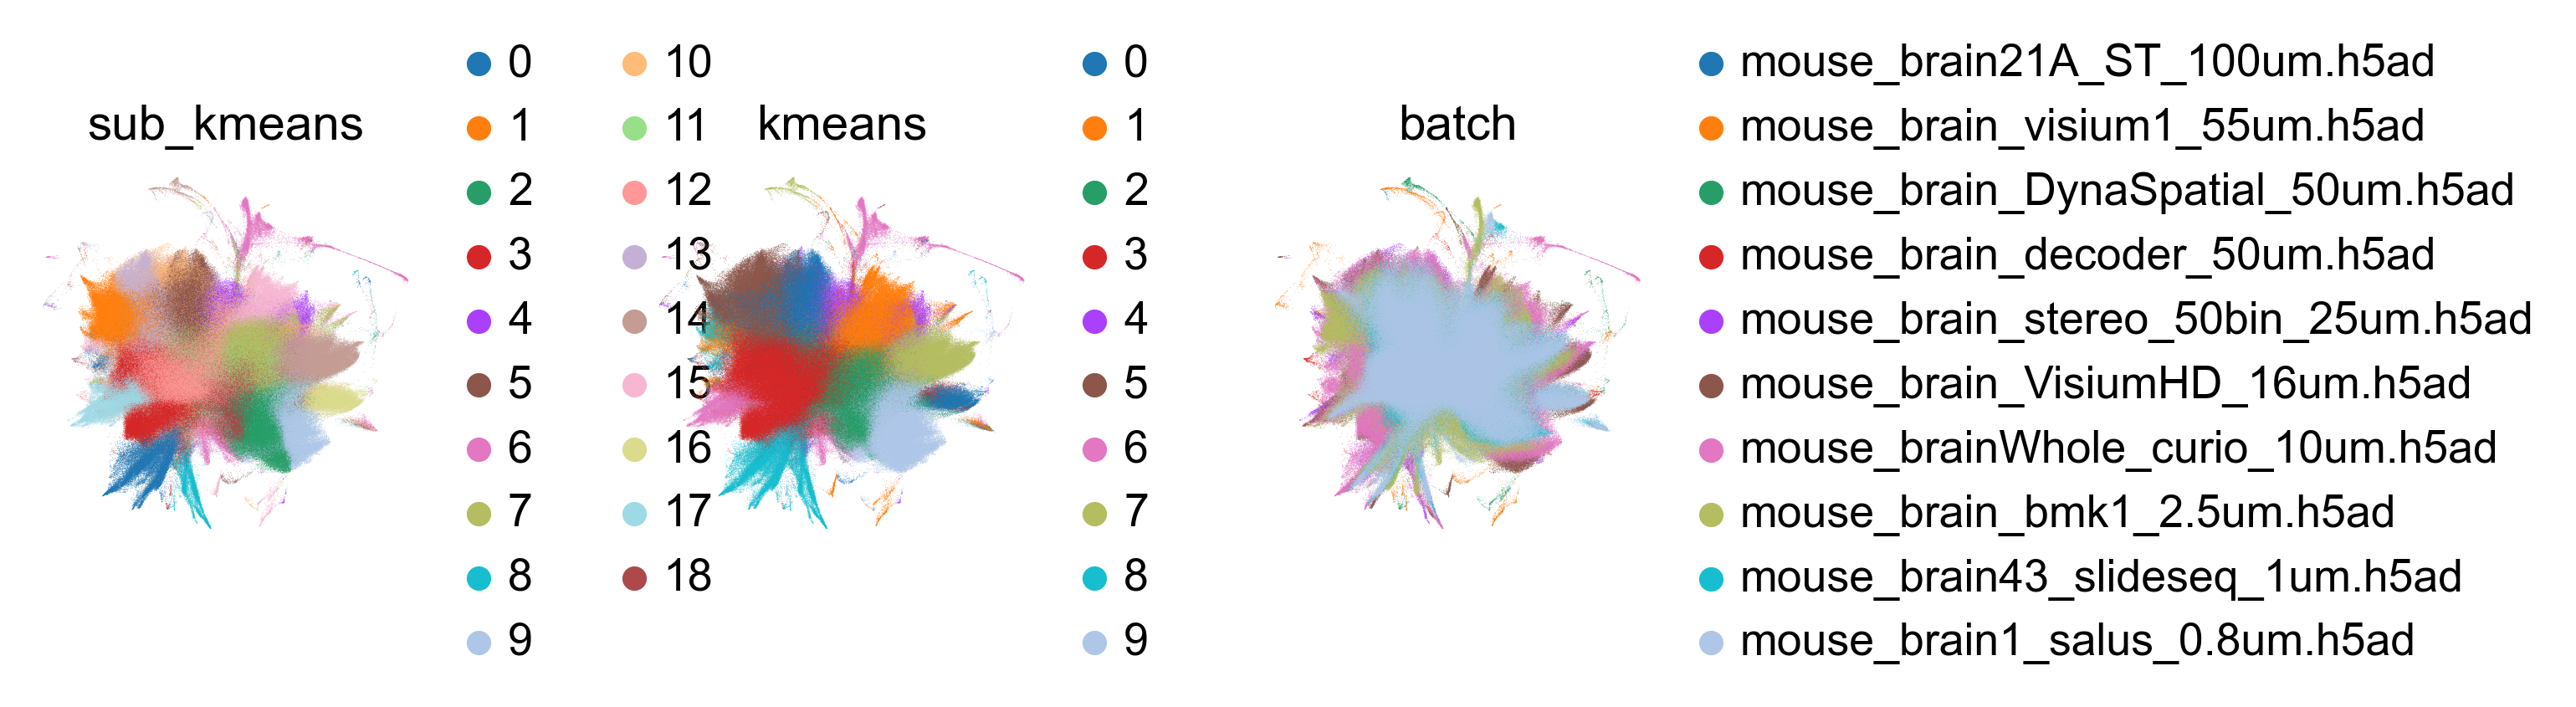

In [21]:
sc.pl.umap(adata_int, color=['sub_kmeans', 'kmeans', 'batch'], ncols=6)

In [22]:
batch_names = adata_int.obs.loc[:, 'batch'].unique()

mouse_brain21A_ST_100um.h5ad


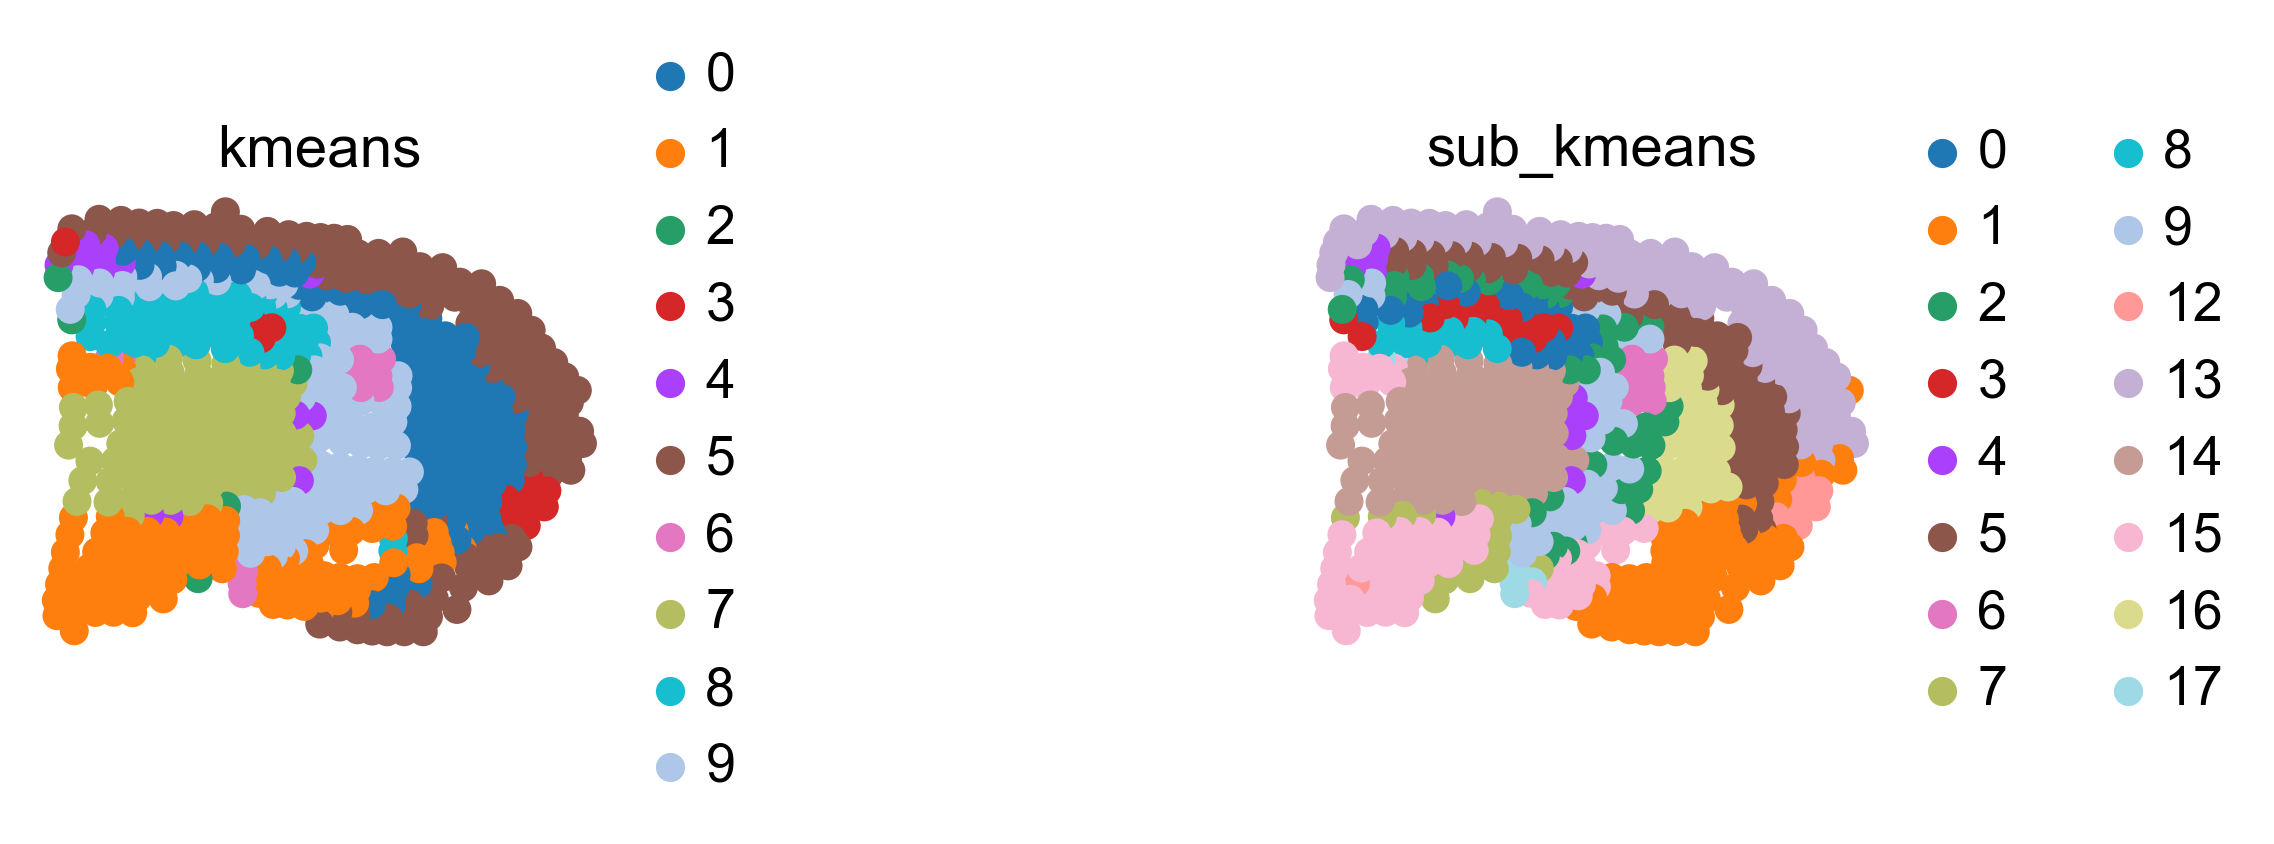

mouse_brain_visium1_55um.h5ad


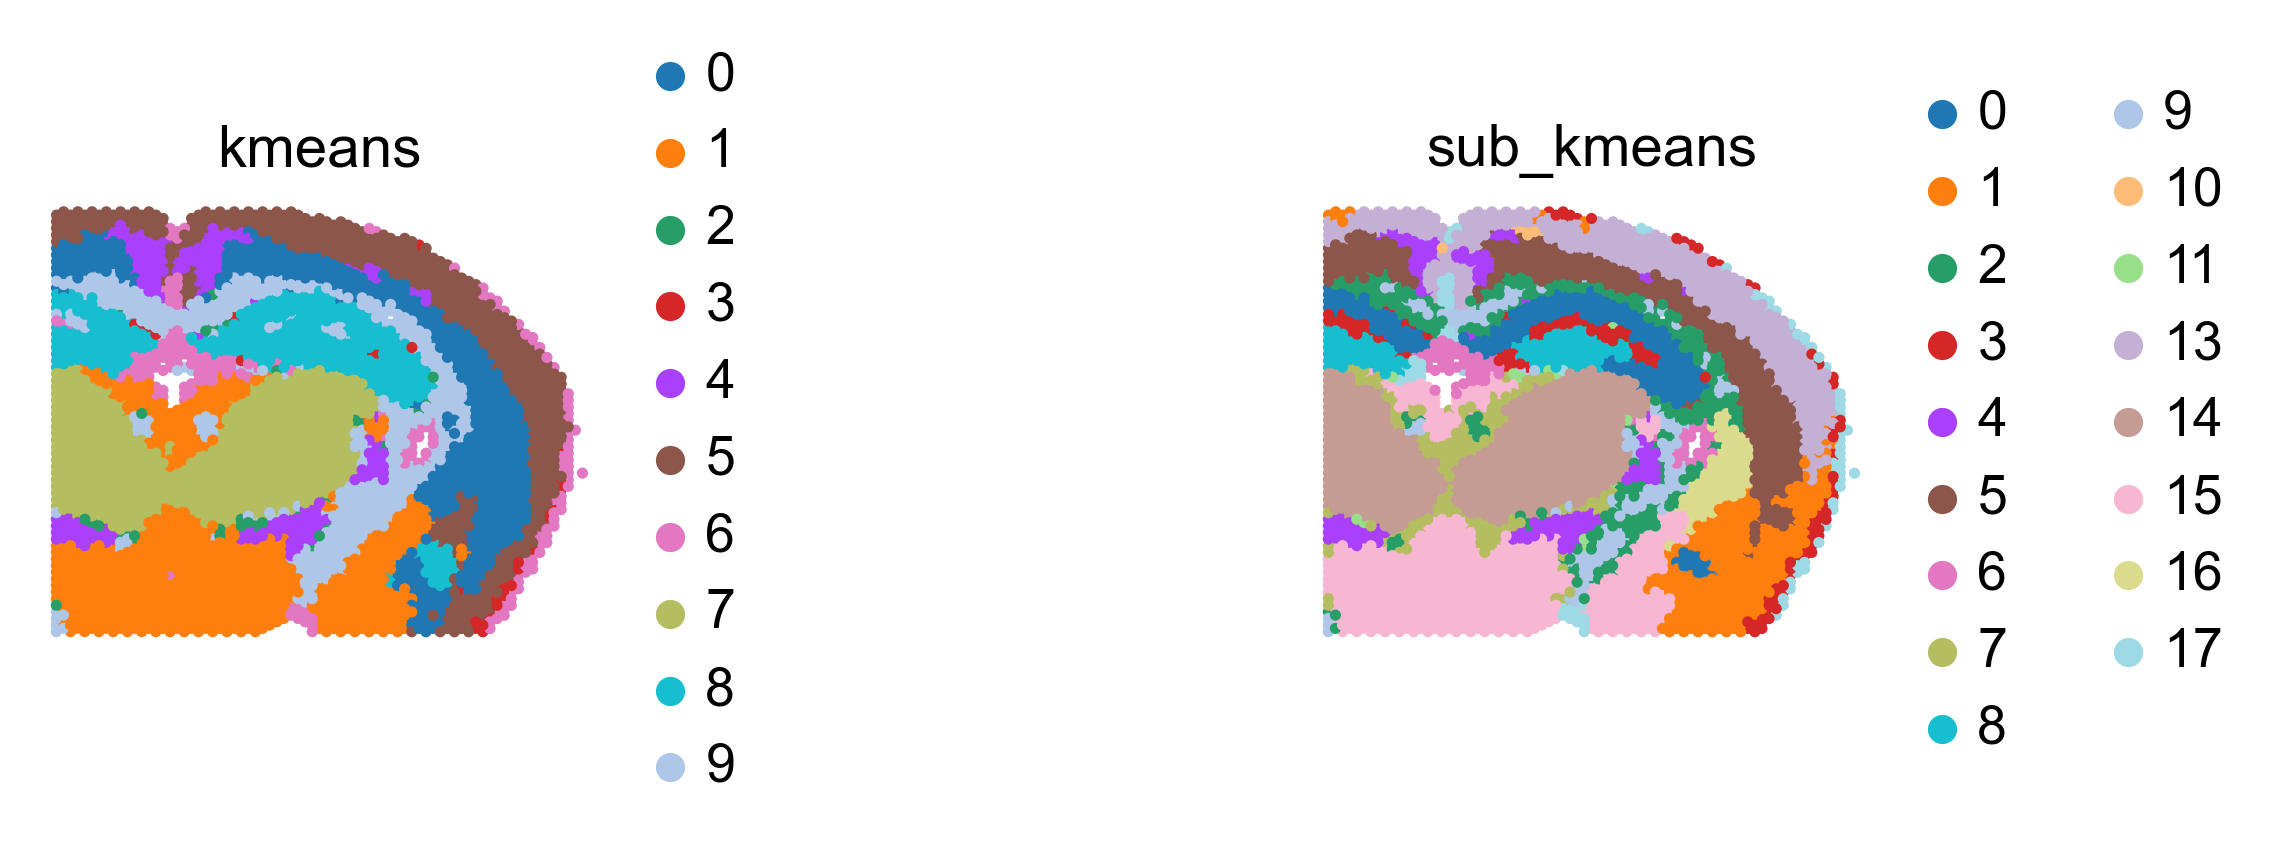

mouse_brain_DynaSpatial_50um.h5ad


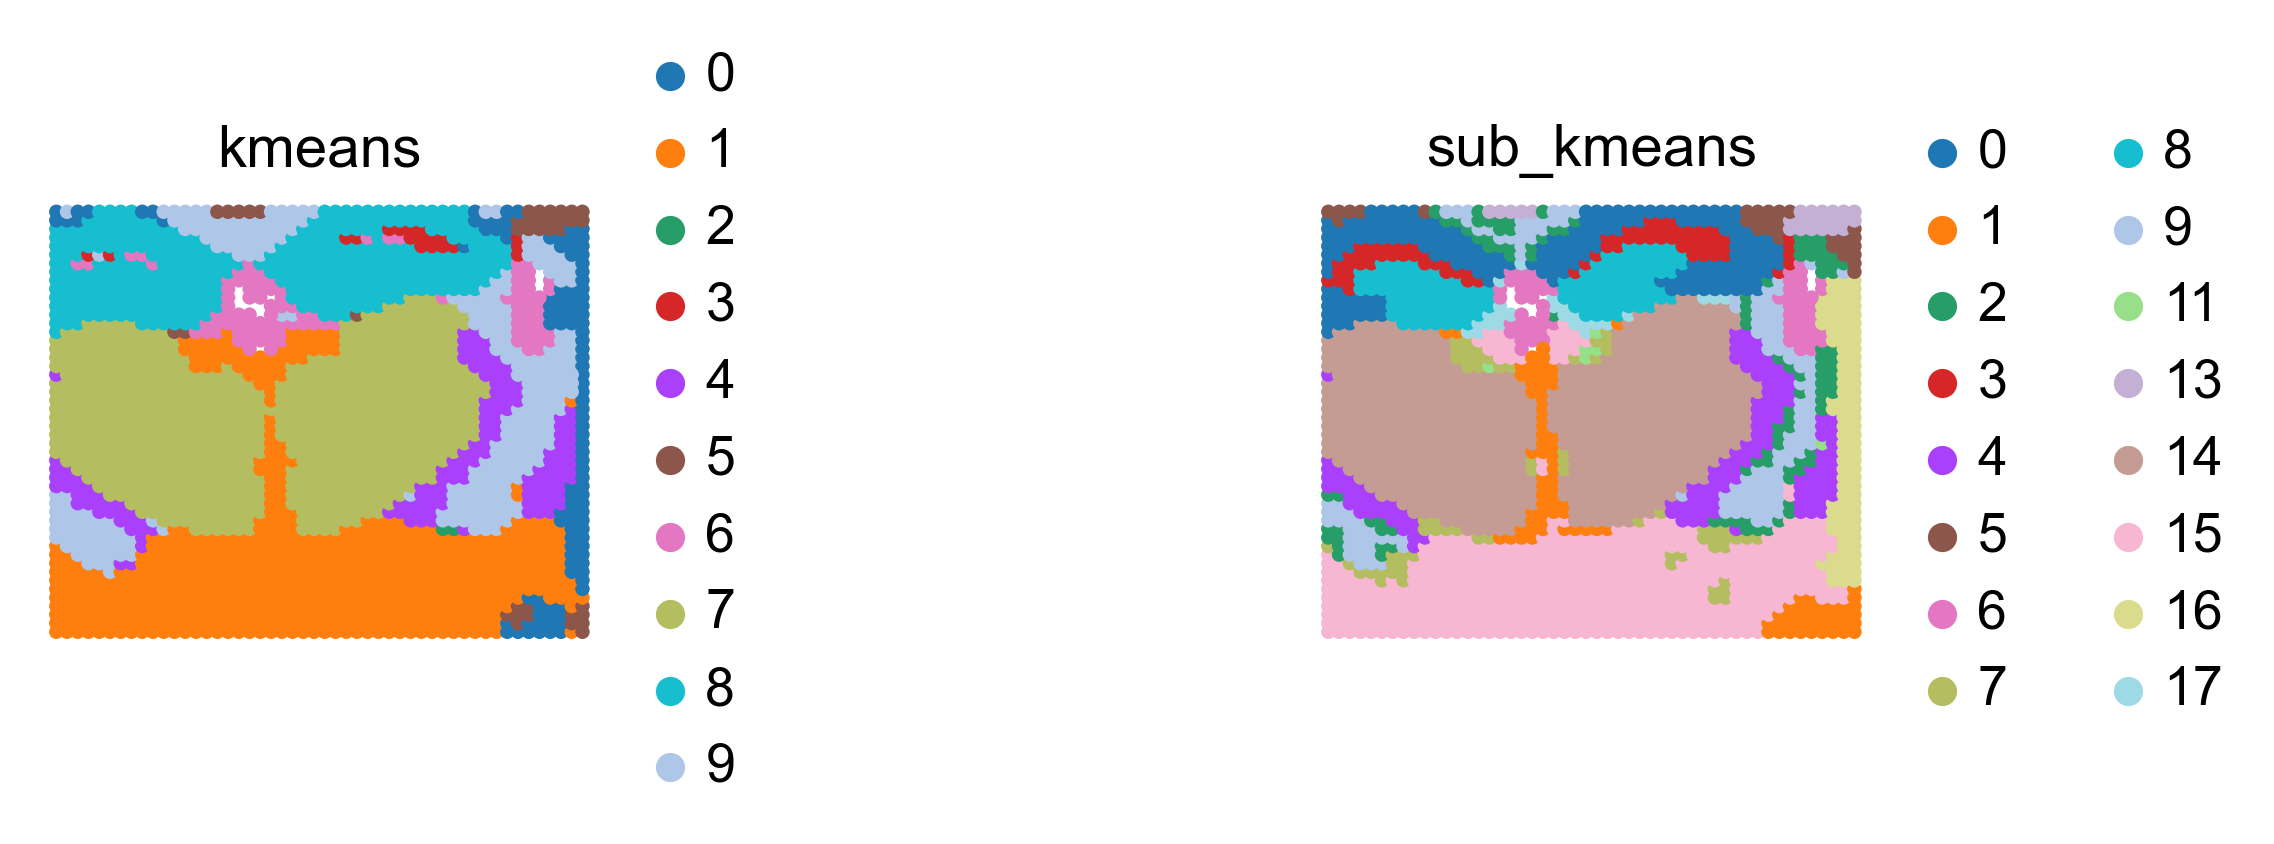

mouse_brain_decoder_50um.h5ad


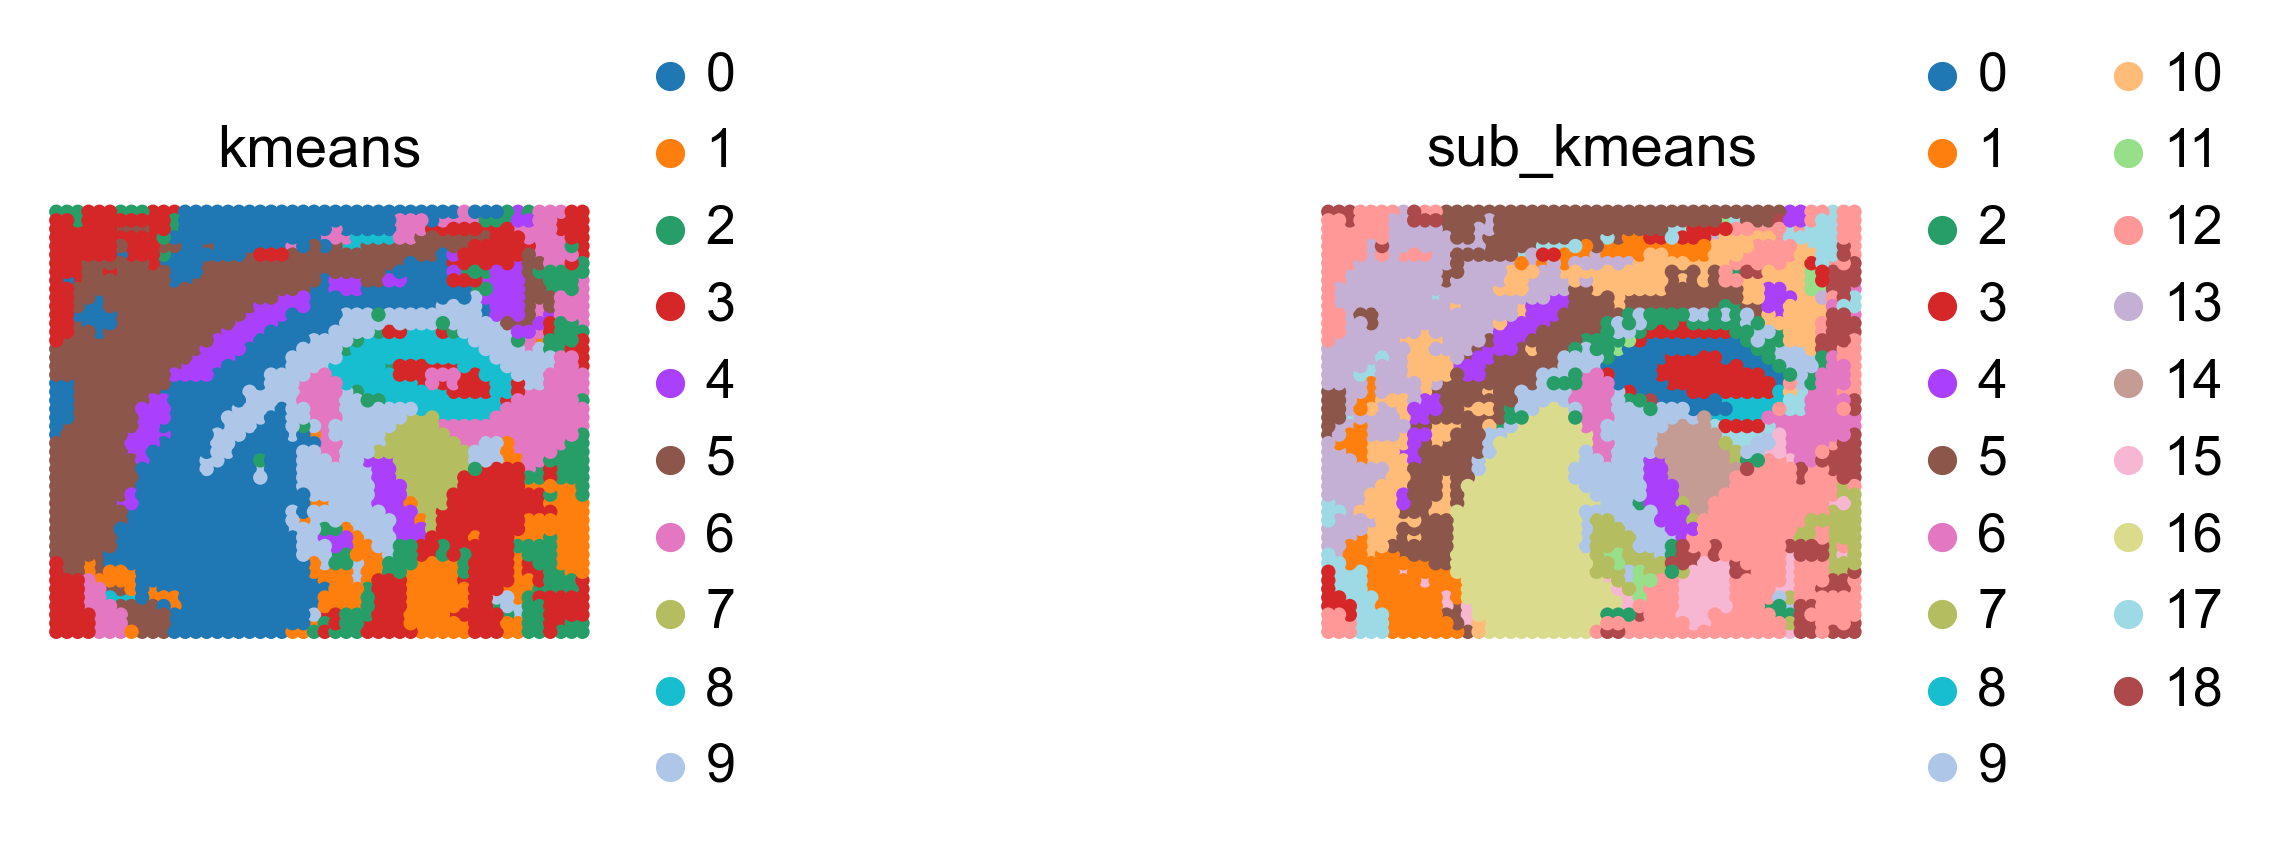

mouse_brain_stereo_50bin_25um.h5ad


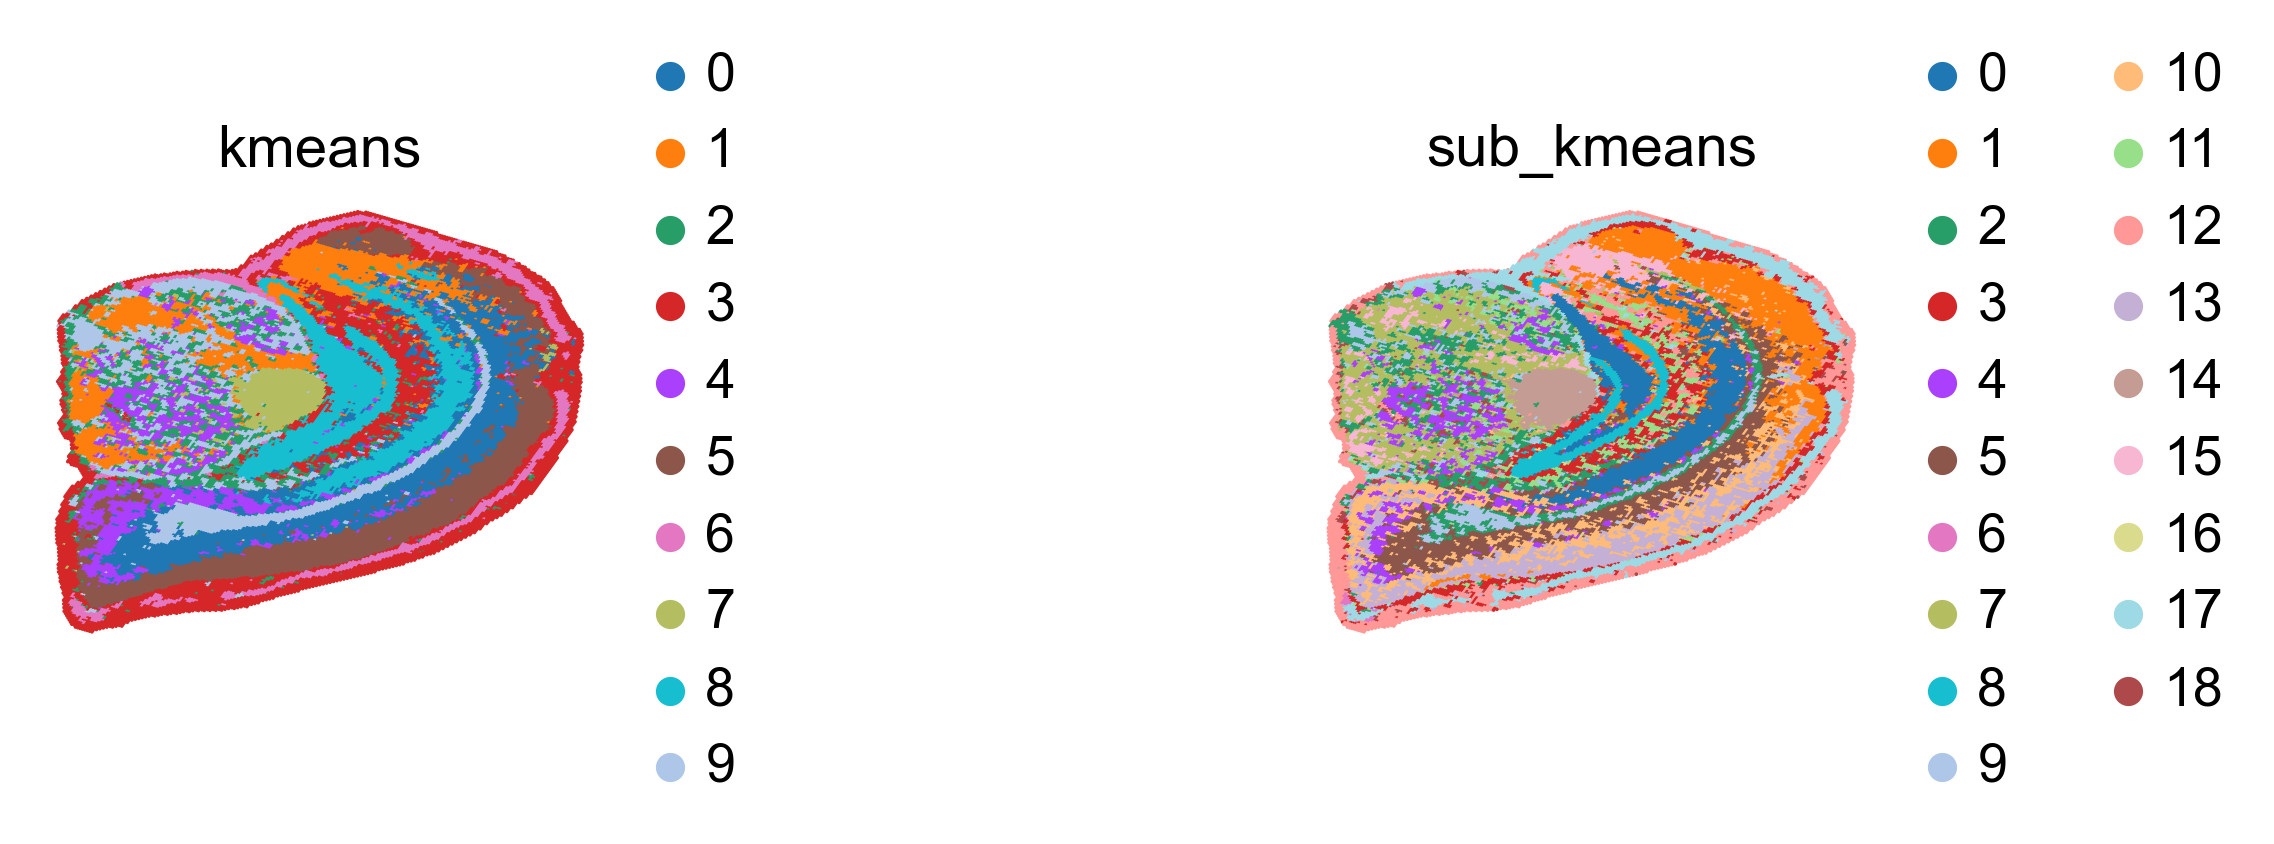

mouse_brain_VisiumHD_16um.h5ad


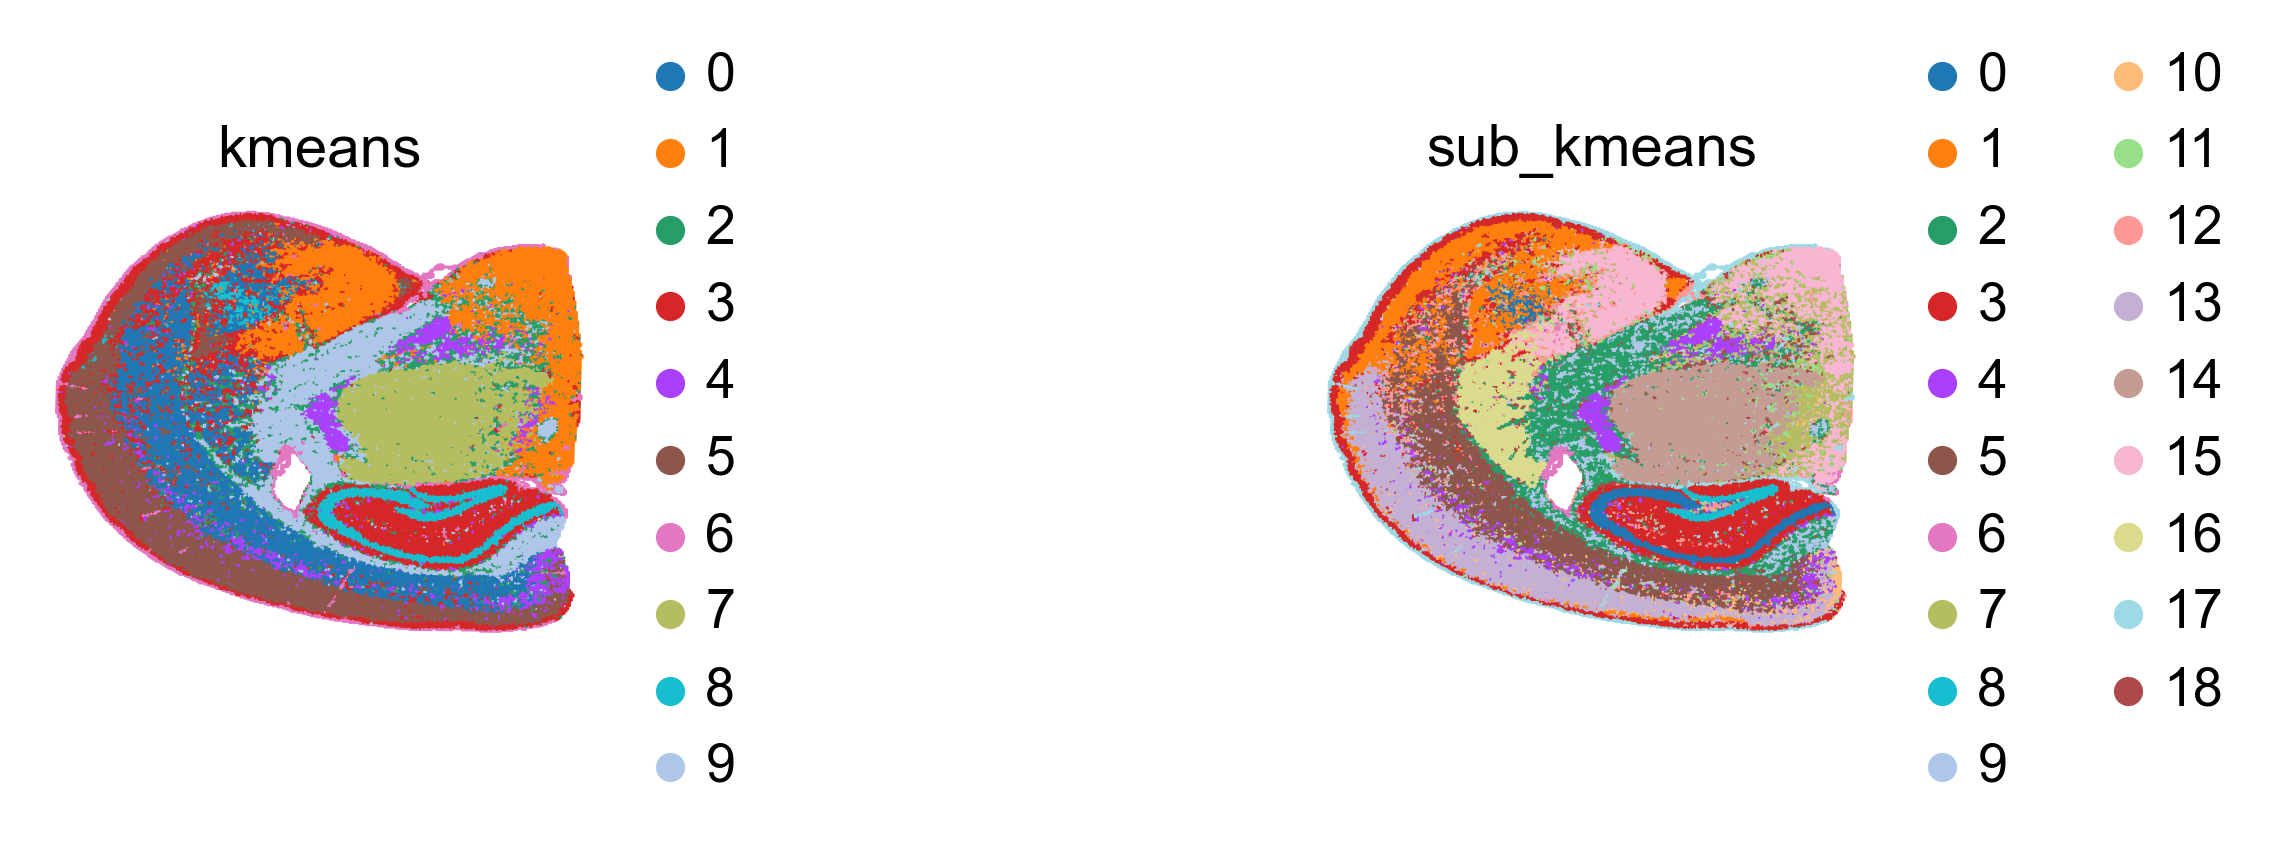

mouse_brainWhole_curio_10um.h5ad


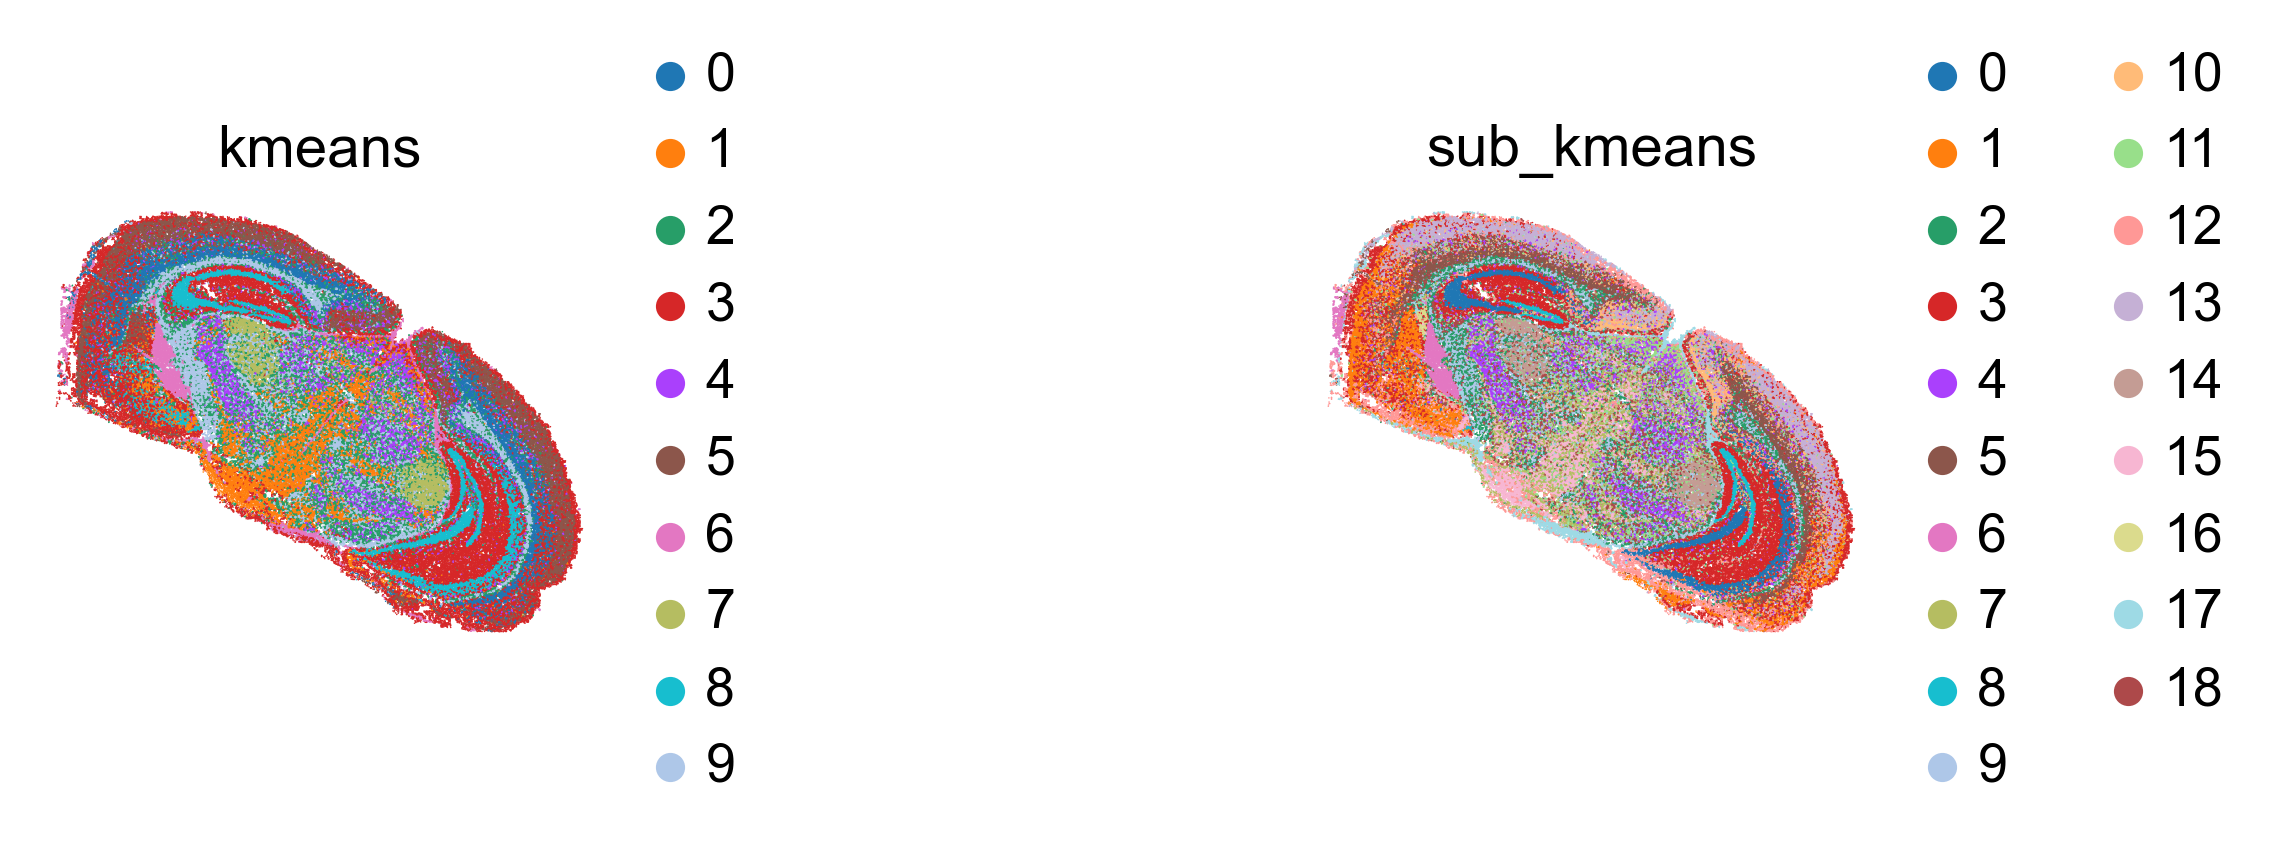

mouse_brain_bmk1_2.5um.h5ad


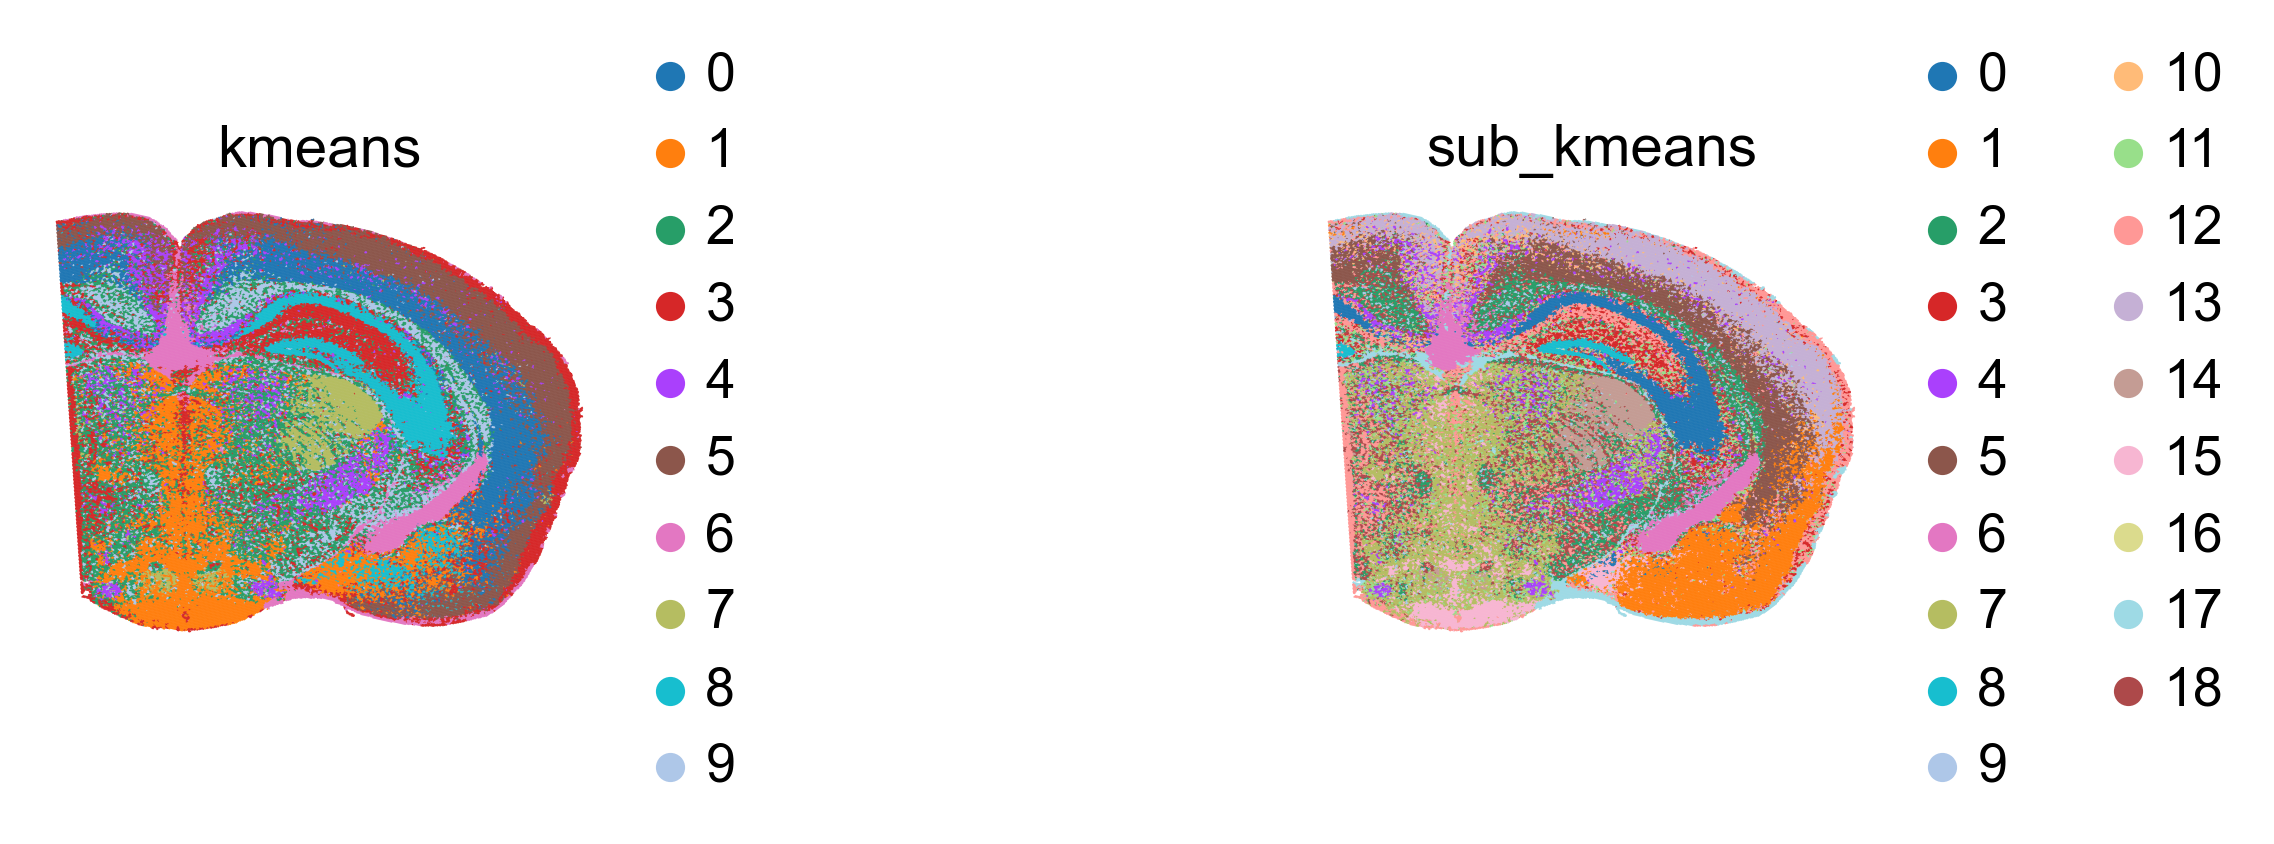

mouse_brain43_slideseq_1um.h5ad


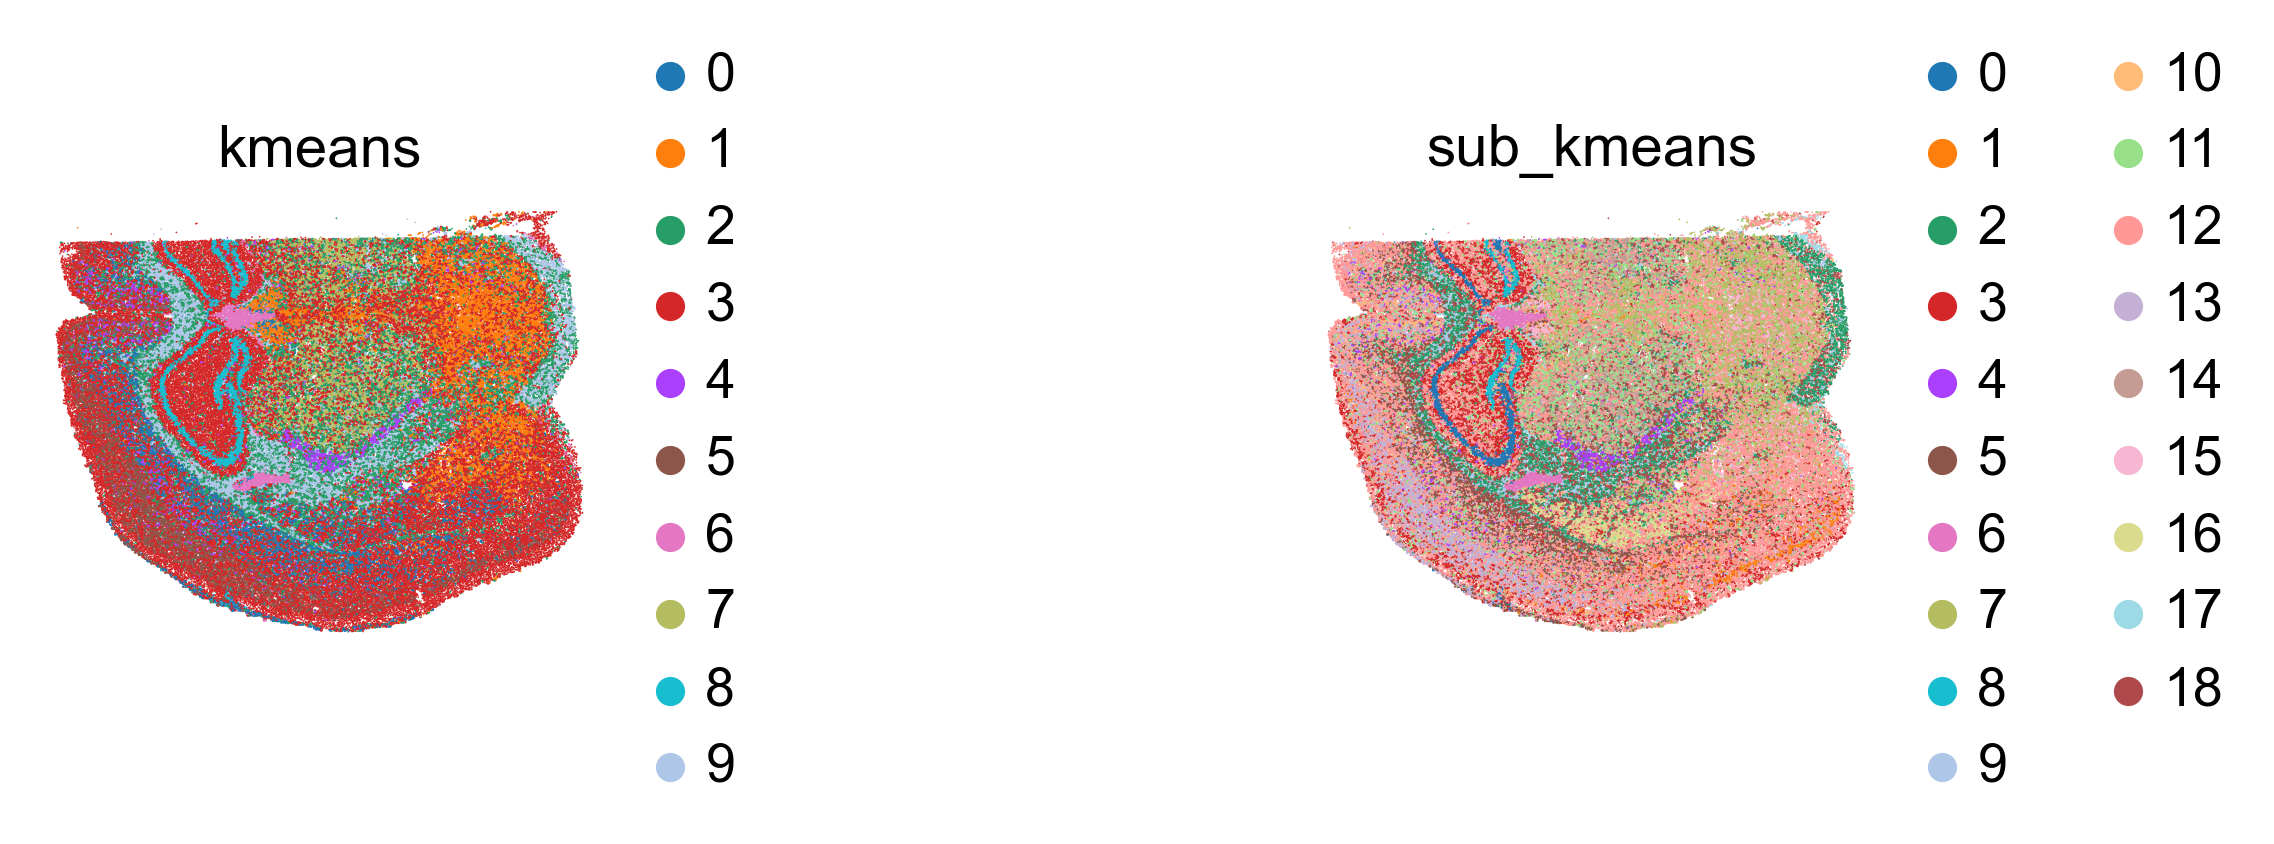

mouse_brain1_salus_0.8um.h5ad


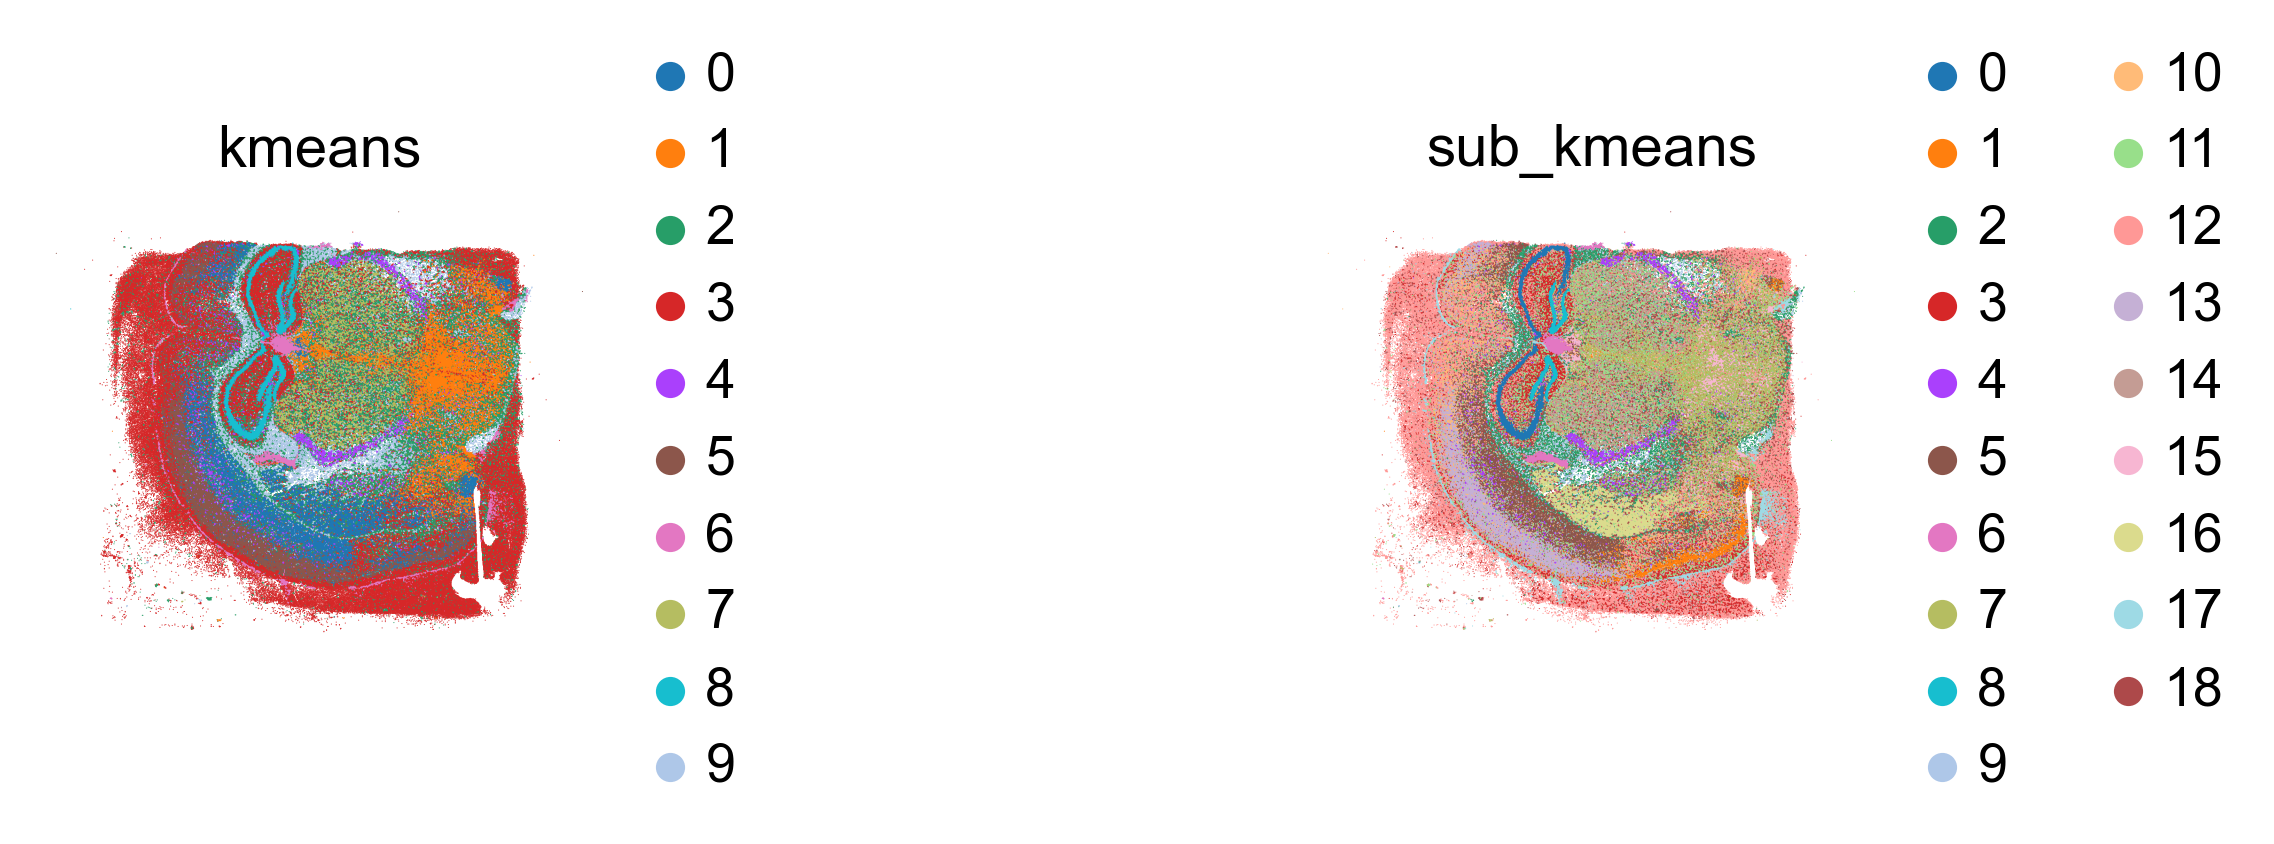

In [23]:
for batch in batch_names:
    temp = adata_int[adata_int.obs.loc[:, 'batch'] == batch, :]
    print(batch)
    sc.pl.embedding(temp, color=['kmeans', 'sub_kmeans'], ncols=5, basis='spatial', wspace=1)